In [ ]:
from tensorflow import keras

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
import matplotlib.pyplot as plt


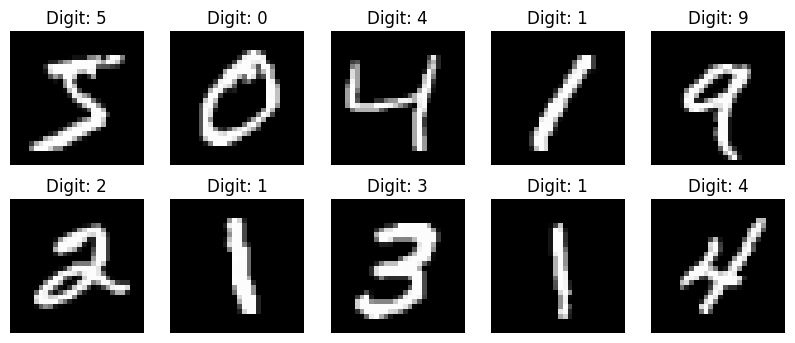

In [ ]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Digit: " + str(y_train[i]))
    plt.axis('off')

plt.show()

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9213 - loss: 0.2746 - val_accuracy: 0.9635 - val_loss: 0.1306
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9649 - loss: 0.1191 - val_accuracy: 0.9742 - val_loss: 0.0954
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9752 - loss: 0.0821 - val_accuracy: 0.9757 - val_loss: 0.0844
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9820 - loss: 0.0608 - val_accuracy: 0.9750 - val_loss: 0.0779
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9853 - loss: 0.0468 - val_accuracy: 0.9773 - val_loss: 0.0815


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9755 - loss: 0.0761
Test Accuracy: 0.9754999876022339
Test Loss: 0.07607542723417282


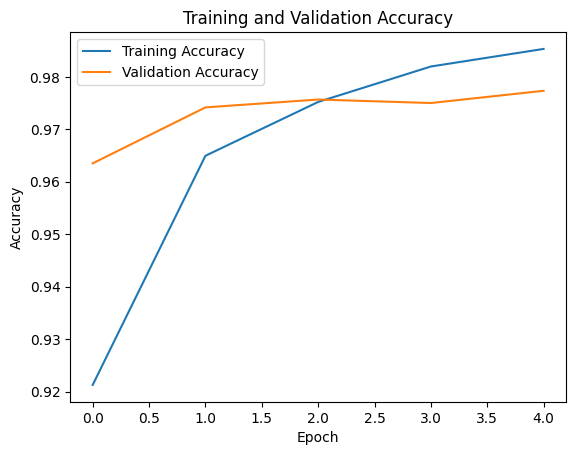

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

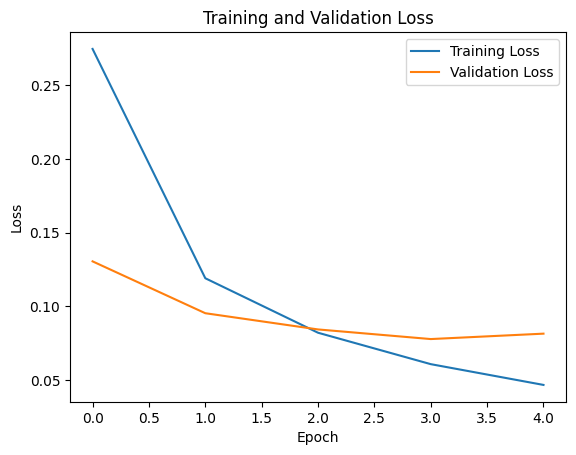

In [ ]:
# Loss graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


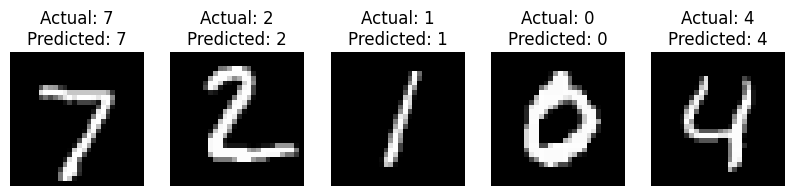

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Actual: {y_test[i]}\nPredicted: {predicted_labels[i]}")
    plt.axis('off')

plt.show()

In [ ]:
model2 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9291 - loss: 0.2442 - val_accuracy: 0.9695 - val_loss: 0.1070
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9693 - loss: 0.1018 - val_accuracy: 0.9770 - val_loss: 0.0806
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9798 - loss: 0.0653 - val_accuracy: 0.9773 - val_loss: 0.0789
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9854 - loss: 0.0474 - val_accuracy: 0.9798 - val_loss: 0.0676
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9885 - loss: 0.0363 - val_accuracy: 0.9795 - val_loss: 0.0685


In [ ]:
test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test)

print("Original Model Test Accuracy:", test_accuracy)
print("Modified Model Test Accuracy:", test_accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9757 - loss: 0.0774
Original Model Test Accuracy: 0.9754999876022339
Modified Model Test Accuracy: 0.9757000207901001


In [ ]:
print("===== MODEL COMPARISON =====")
print("Original Model Accuracy :", test_accuracy)
print("Modified Model Accuracy:", test_accuracy2)

print("\nOriginal Model Accuracy :", test_accuracy * 100, "%")
print("Modified Model Accuracy:", test_accuracy2 * 100, "%")

===== MODEL COMPARISON =====
Original Model Accuracy : 0.9754999876022339
Modified Model Accuracy: 0.9757000207901001

Original Model Accuracy : 97.54999876022339 %
Modified Model Accuracy: 97.57000207901001 %
